In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('cleaned_dataset.csv')
df.head()

C:\Users\mihir\AppData\Local\Temp\ipykernel_34936\795541288.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cleaned_dataset.csv')


,asteroid_id,asteroid_name,near_earth_object,potentially_hazardous,absolute_magnitude,diameter_km,surface_reflectivity,diameter_uncertainty_km,orbit_solution_id,orbit_epoch,...,uncertainty_orbital_inclination,uncertainty_longitude_ascending_node,uncertainty_argument_perihelion,uncertainty_mean_anomaly,uncertainty_aphelion_distance,uncertainty_mean_motion,uncertainty_time_perihelion_passage,uncertainty_orbital_period,asteroid_class,orbit_fit_rms
0,2000001,1 Ceres,False,False,3.40,939.400,0.0900,0.200,JPL 47,2458600.5,...,4.610000e-09,6.170000e-08,6.620000e-08,7.820000e-09,1.110000e-11,1.200000e-12,3.780000e-08,9.420000e-09,MBA,0.43301
1,2000002,2 Pallas,False,False,4.20,545.000,0.1010,18.000,JPL 37,2459000.5,...,3.470000e-06,6.270000e-06,9.130000e-06,8.860000e-06,4.960000e-09,4.650000e-10,4.080000e-05,3.680000e-06,MBA,0.35936
2,2000003,3 Juno,False,False,5.33,246.596,0.2140,10.594,JPL 112,2459000.5,...,3.220000e-06,1.660000e-05,1.770000e-05,8.110000e-06,4.360000e-09,4.410000e-10,3.530000e-05,3.110000e-06,MBA,0.33848
3,2000004,4 Vesta,False,False,3.00,525.400,0.4228,0.200,JPL 35,2458600.5,...,2.170000e-07,3.880000e-07,1.790000e-07,1.210000e-06,1.650000e-09,2.610000e-10,4.100000e-06,1.270000e-06,MBA,0.39980
4,2000005,5 Astraea,False,False,6.90,106.699,0.2740,3.140,JPL 114,2459000.5,...,2.740000e-06,2.890000e-05,2.980000e-05,8.300000e-06,4.730000e-09,5.520000e-10,3.470000e-05,3.490000e-06,MBA,0.52191


In [3]:
# Check unique values in the column
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())

# Check data types
print(df[["potentially_hazardous", "near_earth_object"]].dtypes)


Unique values in 'potentially_hazardous': [False True 'FALSE' 'N' 'TRUE']
Unique values in 'near_earth_object': [False True 'FALSE' 'TRUE' 'Unknown']
potentially_hazardous    object
near_earth_object        object
dtype: object


In [4]:
# Convert all values to uppercase strings for consistency
df["potentially_hazardous"] = df["potentially_hazardous"].astype(str).str.upper()
df["near_earth_object"] = df["near_earth_object"].astype(str).str.upper()

# Define mappings
hazardous_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "N": 0  # 'N' treated as non-hazardous
}

neo_mapping = {
    "TRUE": 1, 
    "FALSE": 0, 
    "UNKNOWN": 0  # assuming 'Unknown' means not confirmed as NEO
}

# Apply mappings and convert to int
df["potentially_hazardous"] = df["potentially_hazardous"].map(hazardous_mapping).astype(int)
df["near_earth_object"] = df["near_earth_object"].map(neo_mapping).astype(int)


In [5]:
# Check unique values again to confirm proper conversion
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())


Unique values in 'potentially_hazardous': [0 1]
Unique values in 'near_earth_object': [0 1]


In [6]:
# Keep only the relevant columns for Naïve Bayes modeling
expanded_features = [
    'absolute_magnitude',
    'diameter_km',
    'semi_major_axis_au',
    'aphelion_distance_au',
    'perihelion_distance_au',
    'orbital_inclination_deg',
    'mean_motion_deg_day',
    'earth_moid_au',
    'orbital_period_days',
    'uncertainty_eccentricity',
    'uncertainty_mean_anomaly',
    'near_earth_object'
]




In [7]:
df_nb = df[expanded_features].copy()

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# Select features and target
X_dt = df_nb[expanded_features].copy()
y_dt = df['potentially_hazardous']

# Handle missing values
X_dt = X_dt.fillna(0)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_dt_resampled, y_dt_resampled = smote.fit_resample(X_dt, y_dt)

# Split into train/test
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt_resampled, y_dt_resampled, test_size=0.3, random_state=42, stratify=y_dt_resampled
)



Training Set Sample:
         absolute_magnitude  diameter_km  semi_major_axis_au  \
1142643           21.564120   -13.058487            1.653115   
1273678           21.363492   -16.917040            1.323538   
1566238           20.331135   -10.228920            2.013004   
1863626           21.139674   -11.758118            2.489833   
912649            16.800000    -2.274049            2.603813   

         aphelion_distance_au  perihelion_distance_au  \
1142643              2.582306                0.723925   
1273678              1.805357                0.841719   
1566238              3.093316                0.932692   
1863626              4.009882                0.969783   
912649               2.676980                2.530646   

         orbital_inclination_deg  mean_motion_deg_day  earth_moid_au  \
1142643                 3.991899             0.463714       0.040862   
1273678                 4.087786             0.647292       0.017849   
1566238                 4.554968   

In [10]:
X_train_dt.head()

,absolute_magnitude,diameter_km,semi_major_axis_au,aphelion_distance_au,perihelion_distance_au,orbital_inclination_deg,mean_motion_deg_day,earth_moid_au,orbital_period_days,uncertainty_eccentricity,uncertainty_mean_anomaly,near_earth_object
1142643,21.564120,-13.058487,1.653115,2.582306,0.723925,3.991899,0.463714,0.040862,776.342495,1.496480e-05,0.010648,1
1273678,21.363492,-16.917040,1.323538,1.805357,0.841719,4.087786,0.647292,0.017849,556.164499,6.762889e-08,0.000063,1
1566238,20.331135,-10.228920,2.013004,3.093316,0.932692,4.554968,0.345094,0.018024,1043.194858,1.240643e-06,0.000222,1
1863626,21.139674,-11.758118,2.489833,4.009882,0.969783,12.316719,0.250871,0.047758,1435.007356,1.200111e-05,0.009811,1
912649,16.800000,-2.274049,2.603813,2.676980,2.530646,12.684295,0.234579,1.521490,1534.662905,4.600000e-08,0.000131,0


In [11]:
X_test_dt.head()

,absolute_magnitude,diameter_km,semi_major_axis_au,aphelion_distance_au,perihelion_distance_au,orbital_inclination_deg,mean_motion_deg_day,earth_moid_au,orbital_period_days,uncertainty_eccentricity,uncertainty_mean_anomaly,near_earth_object
91270,16.300,-0.701949,2.217779,2.474199,1.961360,7.538036,0.298419,0.986811,1206.357236,5.430000e-08,0.000026,0
848197,16.800,0.440144,2.600996,3.398800,1.803192,32.638181,0.234960,0.891414,1532.173358,6.370000e-07,0.000474,0
627503,16.892,0.312146,3.147173,3.413348,2.880998,7.851920,0.176532,1.898000,2039.291951,2.880000e-07,0.000111,0
286425,15.500,6.107554,3.060735,3.930460,2.191009,14.074440,0.184063,1.204360,1955.856317,4.250000e-08,0.000015,0
61472,14.600,6.384394,2.789212,2.816161,2.762263,3.791380,0.211583,1.760690,1701.456166,5.760000e-08,0.000206,0


In [12]:
y_train_dt.value_counts()

potentially_hazardous
1    669521
0    669520
Name: count, dtype: int64

In [13]:
y_test_dt.value_counts()

potentially_hazardous
0    286938
1    286937
Name: count, dtype: int64

🌳 Tree 1 (GINI) Accuracy: 0.9999424961881943


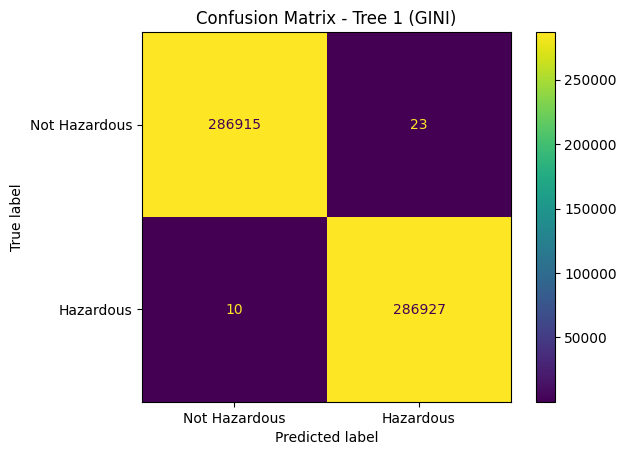

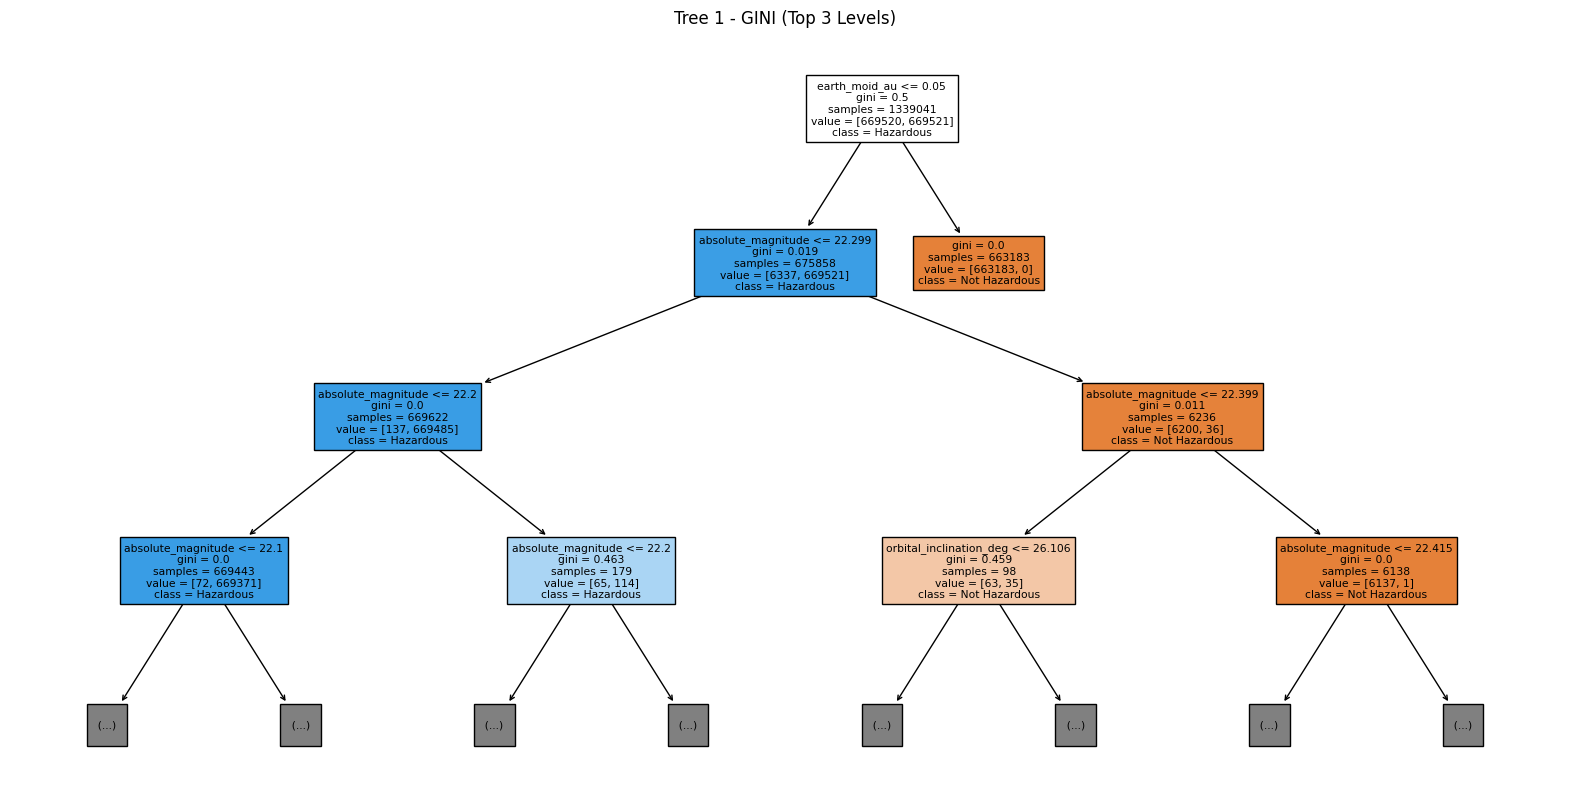

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tree 1 – GINI criterion, default depth
tree1 = DecisionTreeClassifier(criterion="gini", random_state=42)
tree1.fit(X_train_dt, y_train_dt)
y_pred_tree1 = tree1.predict(X_test_dt)

print("Tree 1 (GINI) Accuracy:", accuracy_score(y_test_dt, y_pred_tree1))
ConfusionMatrixDisplay.from_predictions(y_test_dt, y_pred_tree1, display_labels=["Not Hazardous", "Hazardous"])
plt.title("Confusion Matrix - Tree 1 (GINI)")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(tree1, filled=True, feature_names=X_train_dt.columns, class_names=["Not Hazardous", "Hazardous"], max_depth=3)
plt.title("Tree 1 - GINI (Top 3 Levels)")
plt.savefig("tree1_gini.png")
plt.show()

🌳 Tree 2 (Entropy, Max Depth=4) Accuracy: 0.9999128730124156


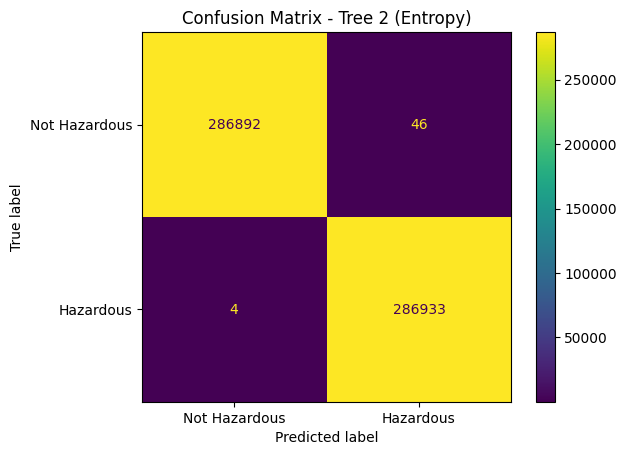

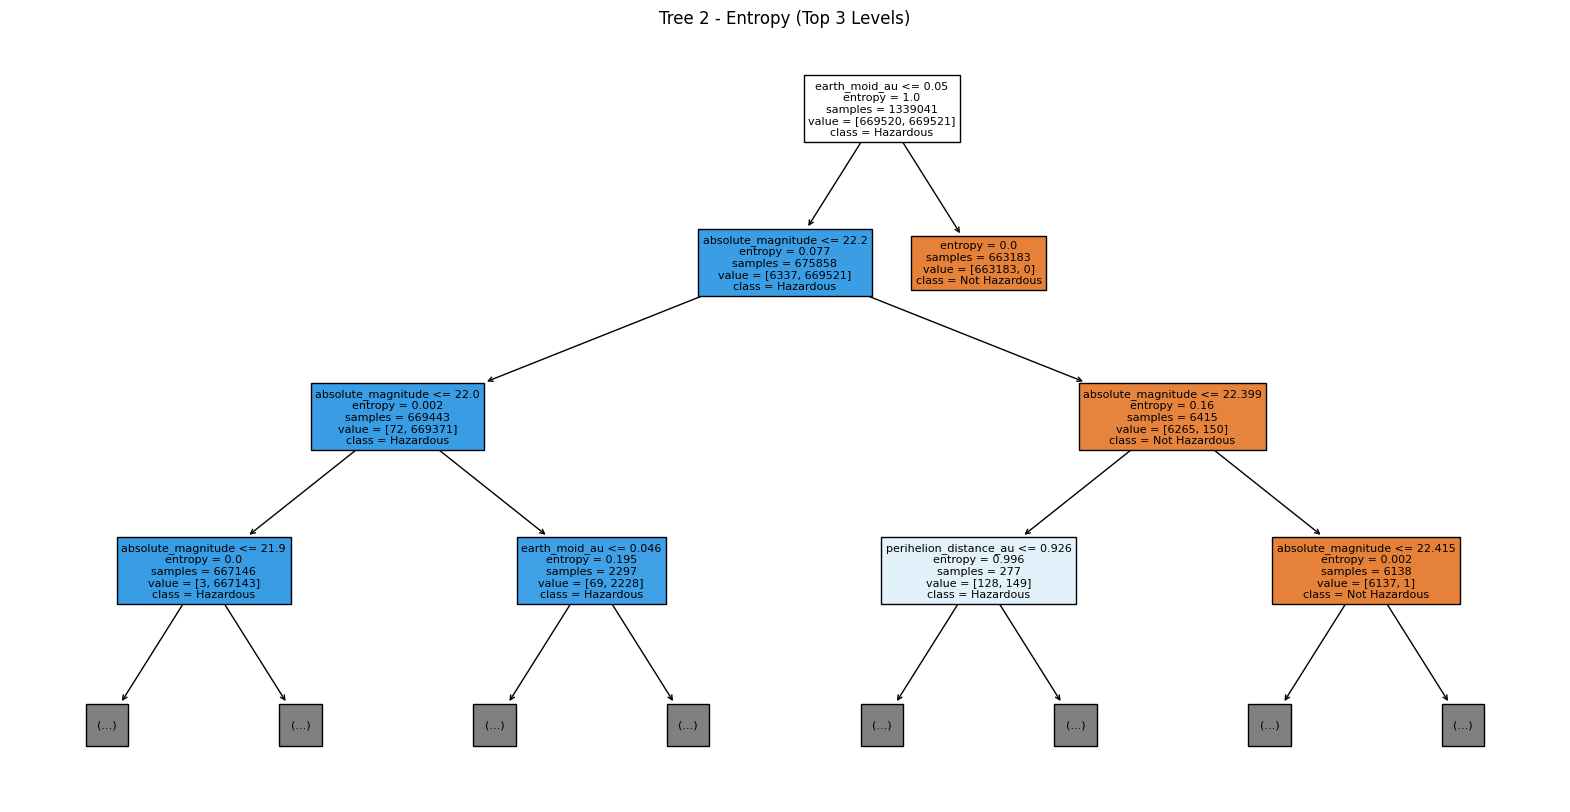

In [16]:
# Tree 2 – ENTROPY criterion, limited depth
tree2 = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
tree2.fit(X_train_dt, y_train_dt)
y_pred_tree2 = tree2.predict(X_test_dt)

print("🌳 Tree 2 (Entropy, Max Depth=4) Accuracy:", accuracy_score(y_test_dt, y_pred_tree2))
ConfusionMatrixDisplay.from_predictions(y_test_dt, y_pred_tree2, display_labels=["Not Hazardous", "Hazardous"])
plt.title("Confusion Matrix - Tree 2 (Entropy)")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(tree2, filled=True, feature_names=X_train_dt.columns, class_names=["Not Hazardous", "Hazardous"], max_depth=3)
plt.title("Tree 2 - Entropy (Top 3 Levels)")
plt.savefig("tree2_entropy.png")
plt.show()

Tree 3 (GINI, min_samples_split=100) Accuracy: 0.999944238727946


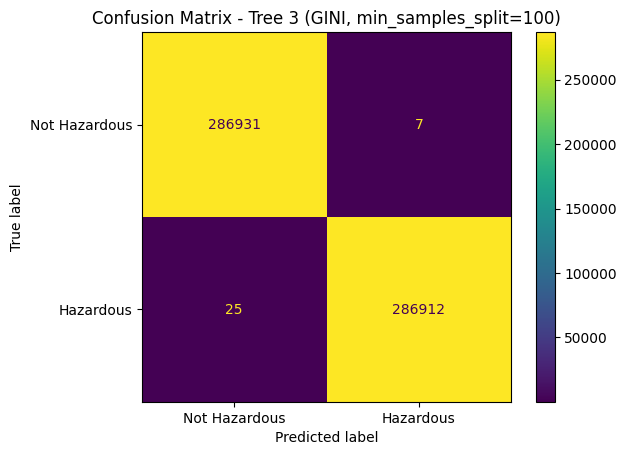

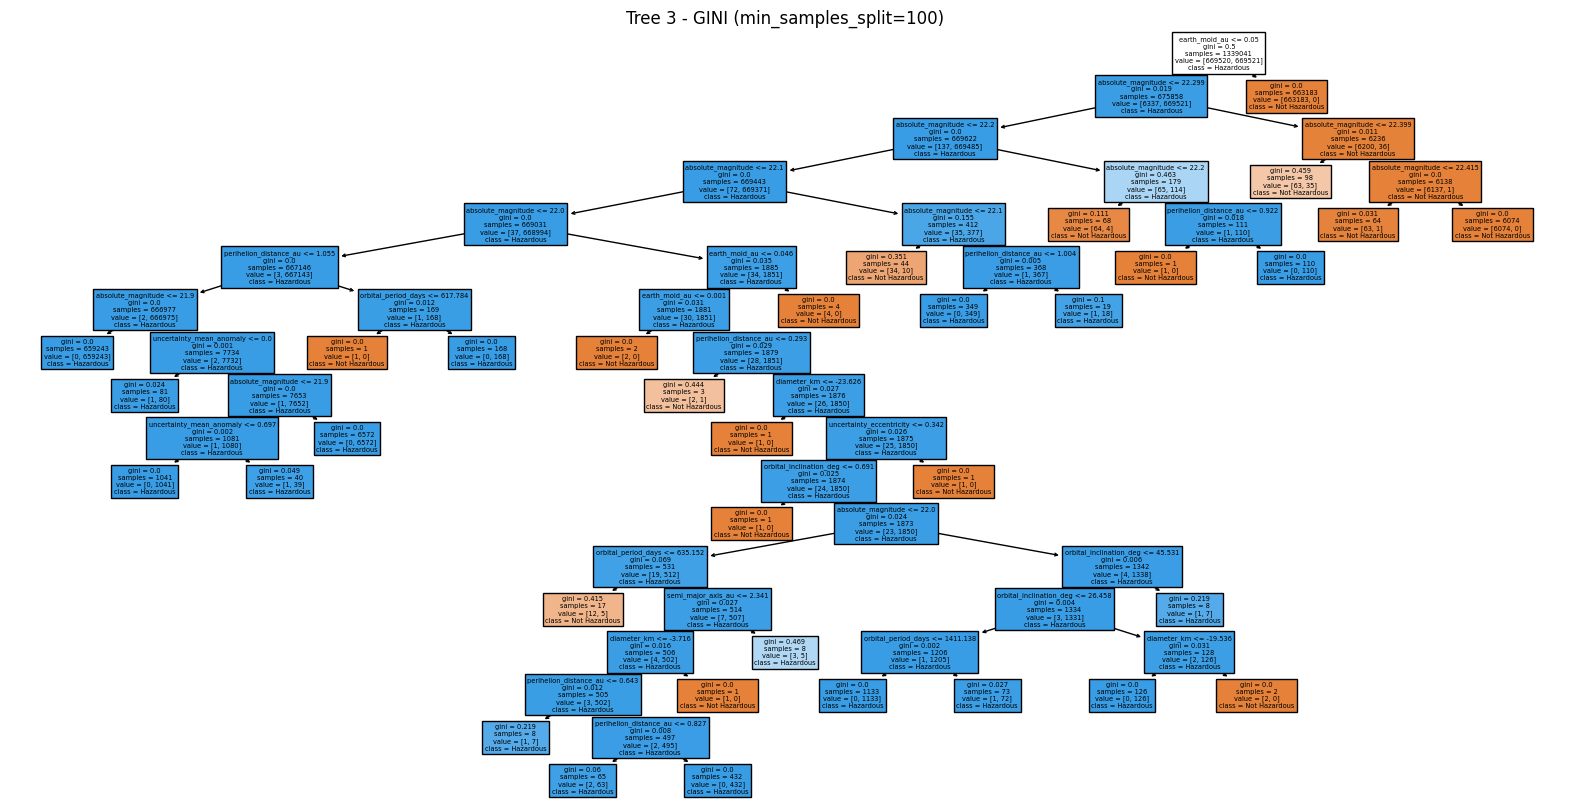

In [19]:

# Tree 3 – GINI + Min Samples Split
tree3 = DecisionTreeClassifier(criterion="gini", min_samples_split=100, random_state=42)
tree3.fit(X_train_dt, y_train_dt)
y_pred_tree3 = tree3.predict(X_test_dt)

print("Tree 3 (GINI, min_samples_split=100) Accuracy:", accuracy_score(y_test_dt, y_pred_tree3))
ConfusionMatrixDisplay.from_predictions(y_test_dt, y_pred_tree3, display_labels=["Not Hazardous", "Hazardous"])
plt.title("Confusion Matrix - Tree 3 (GINI, min_samples_split=100)")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(tree3, filled=True, feature_names=X_train_dt.columns, class_names=["Not Hazardous", "Hazardous"])
plt.title("Tree 3 - GINI (min_samples_split=100)")
plt.savefig("tree3_gini_split.png")
plt.show()

In [ ]:
# Check unique values again to confirm proper conversion
print("Unique values in 'potentially_hazardous':", df["potentially_hazardous"].unique())
print("Unique values in 'near_earth_object':", df["near_earth_object"].unique())


Unique values in 'potentially_hazardous': [0 1]
Unique values in 'near_earth_object': [0 1]
